
## Т13

Проверяем гипотезу о равенстве дисперсий для двух признаков:

- длина черепа: $H_0:\sigma_1^2=\sigma_2^2$;
- ширина черепа: $H_0:\sigma_1^2=\sigma_2^2$.

Будем использовать двусторонний F-критерий при уровне значимости $\alpha=0.05$.
Если
$$F_{obs}=\frac{s_1^2}{s_2^2},$$
то критическая область имеет вид
$$F_{obs}<f_{\alpha/2}(n_1-1,n_2-1) \quad \text{или} \quad F_{obs}>f_{1-\alpha/2}(n_1-1,n_2-1).$$

Функция мощности при параметре
$$\theta=\frac{\sigma_1^2}{\sigma_2^2}$$
задаётся формулой
$$W(\theta)=P_\theta(F< f_{\alpha/2})+P_\theta(F> f_{1-\alpha/2}).$$


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

alpha = 0.05
n_egypt = 139
n_europe = 1000

s_len_egypt = 5.722
s_len_europe = 6.161
s_wid_egypt = 4.612
s_wid_europe = 5.055

def f_test_by_std(std1, std2, n1, n2, alpha=0.05):
    f_obs = (std1 ** 2) / (std2 ** 2)
    q_left = f.ppf(alpha / 2, n1 - 1, n2 - 1)
    q_right = f.ppf(1 - alpha / 2, n1 - 1, n2 - 1)
    p_value = 2 * min(f.cdf(f_obs, n1 - 1, n2 - 1), 1 - f.cdf(f_obs, n1 - 1, n2 - 1))
    reject = (f_obs < q_left) or (f_obs > q_right)
    return f_obs, q_left, q_right, p_value, reject

tests = {
    'Длина': f_test_by_std(s_len_egypt, s_len_europe, n_egypt, n_europe, alpha),
    'Ширина': f_test_by_std(s_wid_egypt, s_wid_europe, n_egypt, n_europe, alpha)
}

for name, (f_obs, q_left, q_right, p_value, reject) in tests.items():
    print(name)
    print(f'  Fнабл = {f_obs:.4f}')
    print(f'  Критическая область: F < {q_left:.4f} или F > {q_right:.4f}')
    print(f'  p-value = {p_value:.4f}')
    print('  Вывод: гипотеза H0 отвергается' if reject else '  Вывод: нет оснований отвергать H0')
    print()


Matplotlib is building the font cache; this may take a moment.


Длина
  Fнабл = 0.8626
  Критическая область: F < 0.7674 или F > 1.2717
  p-value = 0.2728
  Вывод: нет оснований отвергать H0

Ширина
  Fнабл = 0.8324
  Критическая область: F < 0.7674 или F > 1.2717
  p-value = 0.1732
  Вывод: нет оснований отвергать H0




Из вычислений видно, что и для длины, и для ширины наблюдаемое значение статистики попадает в область принятия гипотезы.
Значит, на уровне значимости 0.05 различие стандартных отклонений можно считать случайным.

Так как объёмы выборок одинаковы для обоих признаков, график мощности будет одним и тем же.


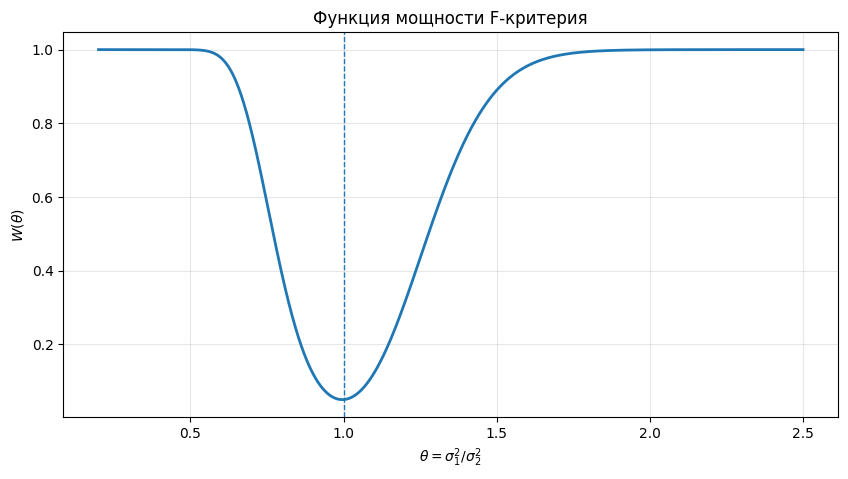

In [2]:

def power_f(theta, df1, df2, alpha=0.05):
    q_left = f.ppf(alpha / 2, df1, df2)
    q_right = f.ppf(1 - alpha / 2, df1, df2)
    return f.cdf(q_left / theta, df1, df2) + 1 - f.cdf(q_right / theta, df1, df2)

theta_grid = np.linspace(0.2, 2.5, 800)
power_values = power_f(theta_grid, n_egypt - 1, n_europe - 1, alpha)

plt.figure(figsize=(10, 5))
plt.plot(theta_grid, power_values, linewidth=2)
plt.axvline(1, linestyle='--', linewidth=1)
plt.xlabel(r'$\theta = \sigma_1^2 / \sigma_2^2$')
plt.ylabel(r'$W(\theta)$')
plt.title('Функция мощности F-критерия')
plt.grid(True, alpha=0.3)
plt.show()
